# Analisis Keterlambatan Pengiriman dan Dampaknya terhadap Kepuasan Pelanggan

## Tujuan
Analisis ini bertujuan untuk memahami pola keterlambatan pengiriman pada platform e-commerce Olist serta dampaknya terhadap kepuasan pelanggan yang diukur melalui review score. Hasil analisis diharapkan dapat memberikan insight berbasis data untuk mendukung pengambilan keputusan bisnis.

## Landasan Teori

### Pengertian Analisis Data
Analisis data adalah proses mengolah dan mengeksplorasi data untuk menemukan pola, tren, dan hubungan yang dapat digunakan sebagai dasar pengambilan keputusan berbasis data.

### Descriptive Analysis vs Exploratory Data Analysis (EDA)
Descriptive analysis berfokus pada ringkasan data untuk menjawab apa yang terjadi, sedangkan EDA bertujuan mengeksplorasi data lebih dalam untuk memahami pola dan hubungan antar variabel.

### Pentingnya Data Cleaning dan Wrangling
Data yang tidak bersih dapat menghasilkan insight yang bias dan menyesatkan. Oleh karena itu, proses pembersihan dan transformasi data menjadi tahap krusial sebelum analisis lanjutan.

### Peran Visualisasi Data
Visualisasi data membantu menyampaikan insight secara intuitif dan memudahkan pemahaman pola yang sulit ditangkap melalui angka mentah.

### Machine Learning (Opsional)
Machine learning digunakan sebagai alat pendukung untuk mengidentifikasi pola dan faktor dominan dalam data, bukan sebagai fokus utama optimasi model.


# Import Library

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load Data

In [125]:
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")

# Memahami Struktur dan Kualitas Data

In [126]:
orders.head(), orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


(                           order_id                       customer_id  \
 0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
 1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
 2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
 3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
 4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
 
   order_status order_purchase_timestamp    order_approved_at  \
 0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
 1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
 2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
 3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
 4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   
 
   order_delivered_carrier_date order_delivered_customer_date  \
 0          2017-10-04 19:55:00           2017-10-10 21:25:13   
 1          2018-07-26 14:31:00 

In [127]:
reviews.head(), reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


(                          review_id                          order_id  \
 0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
 1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
 2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
 3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
 4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   
 
    review_score review_comment_title  \
 0             4                  NaN   
 1             5                  NaN   
 2             5                  NaN   
 3             5                  NaN   
 4             5                  NaN   
 
                               review_comment_message review_creation_date  \
 0                                                NaN  2018-01-18 00:00:00   
 1                                                NaN  2018-03-10 00:00:00   
 2                                                NaN  2018-02-17 00:00:

In [128]:
# Cek ringkas kualitas data
quality_checks = {
    "missing_frac_orders": orders.isnull().mean().sort_values(ascending=False).head(8),
    "missing_frac_reviews": reviews.isnull().mean().sort_values(ascending=False).head(8),
    "duplicates_orders": orders.duplicated().sum(),
    "duplicates_reviews": reviews.duplicated().sum(),
}
quality_checks

{'missing_frac_orders': order_delivered_customer_date    0.029817
 order_delivered_carrier_date     0.017930
 order_approved_at                0.001609
 order_id                         0.000000
 customer_id                      0.000000
 order_status                     0.000000
 order_purchase_timestamp         0.000000
 order_estimated_delivery_date    0.000000
 dtype: float64,
 'missing_frac_reviews': review_comment_title       0.883415
 review_comment_message     0.587025
 review_id                  0.000000
 order_id                   0.000000
 review_score               0.000000
 review_creation_date       0.000000
 review_answer_timestamp    0.000000
 dtype: float64,
 'duplicates_orders': 0,
 'duplicates_reviews': 0}

## Data Cleaning & Transformasi

### Konversi Kolom Tanggal

In [129]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

### Membuat Variabel Keterlambatan

In [130]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days


In [131]:
# Tandai keterlambatan; biarkan NaN jika tanggal tidak lengkap
orders["is_late"] = np.where(
    orders["delivery_delay_days"].notna(),
    (orders["delivery_delay_days"] > 0).astype(int),
    np.nan
)

# Merge Dataset

In [132]:
data = (
    orders
    .merge(reviews, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
)

In [133]:
data = data.dropna(subset=["review_score"])

# Analisis Statistik Deksriptif

In [134]:
data[["delivery_delay_days", "review_score"]].describe()

,delivery_delay_days,review_score
count,96359.000000,99224.000000
mean,-11.917797,4.086421
std,10.114024,1.347579
min,-147.000000,1.000000
25%,-17.000000,4.000000
50%,-12.000000,5.000000
75%,-7.000000,5.000000
max,188.000000,5.000000


In [135]:
data["is_late"].value_counts(normalize=True) * 100

is_late
0.0    93.347793
1.0     6.652207
Name: proportion, dtype: float64

# Pertanyaan Analisis 1 (EDA)

### Apakah keterlambatan pengiriman memengaruhi review score?

In [136]:
data.groupby("is_late")["review_score"].mean()

is_late
0.0    4.289842
1.0    2.271139
Name: review_score, dtype: float64

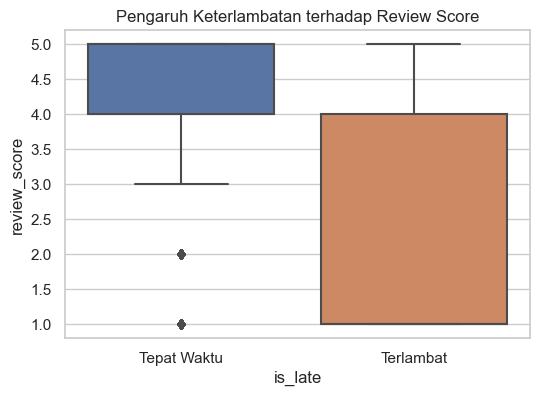

In [137]:
plt.figure(figsize=(6,4))
sns.boxplot(x="is_late", y="review_score", data=data)
plt.xticks([0,1], ["Tepat Waktu", "Terlambat"])
plt.title("Pengaruh Keterlambatan terhadap Review Score")
plt.show()

# Pertanyaan Analisis 2 (EDA)

### Berapa lama rata-rata keterlambatan pengiriman?

In [138]:
data[data["is_late"] == 1]["delivery_delay_days"].describe()

count    6410.000000
mean       10.526833
std        14.445316
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delivery_delay_days, dtype: float64

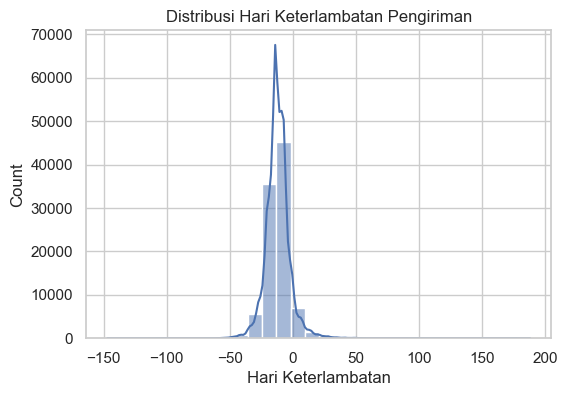

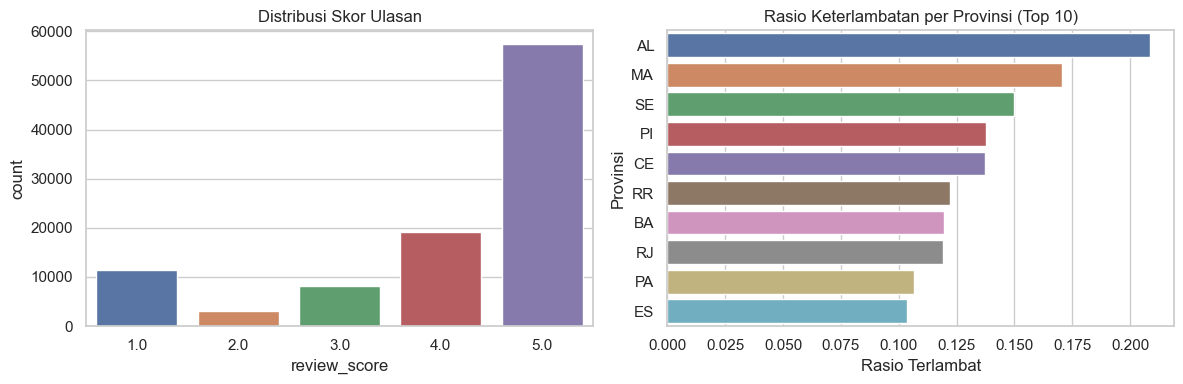

In [142]:
import warnings

delays = data["delivery_delay_days"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(6,4))
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
    sns.histplot(delays, bins=30, kde=True)
plt.title("Distribusi Hari Keterlambatan Pengiriman")
plt.xlabel("Hari Keterlambatan")
plt.show()

# Visualisasi tambahan: distribusi skor ulasan dan keterlambatan per provinsi (top 10)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x="review_score", data=data, ax=axes[0], order=sorted(data["review_score"].unique()))
axes[0].set_title("Distribusi Skor Ulasan")

late_by_state = (
    data.dropna(subset=["is_late"])  # hindari NaN is_late
        .groupby("customer_state")["is_late"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
)
sns.barplot(x=late_by_state.values, y=late_by_state.index, ax=axes[1])
axes[1].set_title("Rasio Keterlambatan per Provinsi (Top 10)")
axes[1].set_xlabel("Rasio Terlambat")
axes[1].set_ylabel("Provinsi")

plt.tight_layout()
plt.show()

# Machine Learning Sederhana (hanya untuk sebagai pembantu insight sesuai dengan yang disuruh)

### Tujuan

### Mengidentifikasi faktor yang berkontribusi terhadap keterlambatan pengiriman.

Teknik: Logistic Regression (klasifikasi sederhana) digunakan untuk memodelkan peluang pelanggan memberi ulasan rendah (≤3) dengan fitur utama terkait keterlambatan (is_late, delivery_delay_days). Model ini dipilih karena mudah diinterpretasi dan cukup untuk melihat arah pengaruh faktor keterlambatan terhadap kepuasan.

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [143]:
# Siapkan data untuk model: prediksi ulasan rendah (<=3)
ml_data = data[["delivery_delay_days", "is_late", "review_score"]].dropna()

X = ml_data[["delivery_delay_days", "is_late"]]
y = (ml_data["review_score"] <= 3).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.98      0.89     15210
           1       0.72      0.23      0.35      4062

    accuracy                           0.82     19272
   macro avg       0.77      0.60      0.62     19272
weighted avg       0.80      0.82      0.78     19272



Baseline accuracy (majority class): 0.789
Model accuracy: 0.819
Balanced accuracy: 0.602


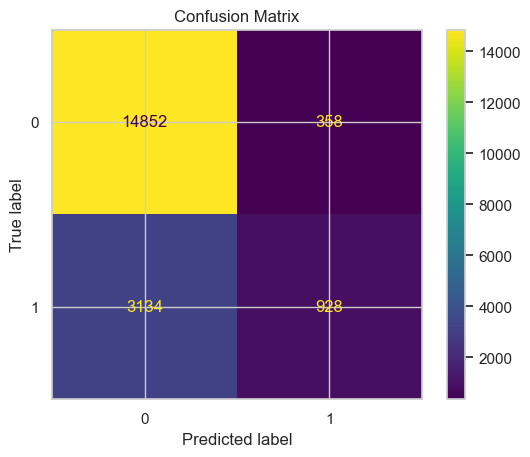

ROC AUC: 0.623


In [144]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    roc_auc_score,
)

# Baseline: selalu tebak kelas mayoritas
baseline_acc = max((y_test == 0).mean(), (y_test == 1).mean())
model_acc = (y_pred == y_test).mean()

print(f"Baseline accuracy (majority class): {baseline_acc:.3f}")
print(f"Model accuracy: {model_acc:.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.3f}")

### Insight & Kesimpulan

### Insight Utama (berdasarkan EDA)

1. **Keterlambatan pengiriman berkorelasi dengan penurunan kepuasan pelanggan.**
   Dari boxplot perbandingan `review_score` antara pesanan tepat waktu vs terlambat, kelompok terlambat cenderung memiliki skor ulasan yang lebih rendah.

2. **Mayoritas pesanan dikirim tepat waktu, namun ada ekor panjang (outlier) keterlambatan.**
   Distribusi `delivery_delay_days` menunjukkan sebagian besar pesanan berada di sekitar 0 hari (bahkan banyak yang lebih cepat dari estimasi), tetapi terdapat sebagian kecil pesanan yang terlambat cukup ekstrem.

3. **Ada perbedaan rasio keterlambatan antar provinsi (customer_state).**
   Visualisasi “Rasio Keterlambatan per Provinsi (Top 10)” memperlihatkan beberapa provinsi memiliki proporsi pesanan terlambat lebih tinggi daripada yang lain. Ini bisa menjadi titik awal investigasi operasional (jarak, kapasitas logistik, lead time vendor, dsb.).

### Catatan Machine Learning (sebagai pendukung insight)

- Model klasifikasi sederhana (Logistic Regression) digunakan untuk memprediksi **ulasan rendah (≤3)** dari fitur terkait keterlambatan (`delivery_delay_days` dan `is_late`). Tujuannya bukan optimasi model, tetapi untuk menguji apakah sinyal keterlambatan cukup kuat untuk menjelaskan kecenderungan ulasan rendah.

- **Mengapa akurasi terlihat bisa lebih rendah dibanding sebelumnya?**
  1) **Masalah kelas tidak seimbang (imbalanced).** Pada banyak kasus, kelas mayoritas mendominasi. Jika model “main aman” dengan selalu menebak kelas mayoritas, **accuracy bisa terlihat tinggi tetapi tidak berguna** untuk mendeteksi kelas minoritas.
  2) Pada model ini kita menggunakan `class_weight="balanced"` agar model lebih memperhatikan kelas minoritas. Dampaknya: model mulai memprediksi kelas minoritas (lebih informatif), namun **accuracy dapat turun** karena trade-off antara false positive dan false negative.
  3) Karena itu, metrik seperti **Balanced Accuracy, Precision/Recall kelas minoritas, dan ROC AUC** lebih relevan untuk menilai performa pada data imbalanced dibanding accuracy saja.

### Kesimpulan

Ketepatan waktu pengiriman merupakan faktor penting dalam menjaga kepuasan pelanggan. Pesanan yang terlambat cenderung memperoleh skor ulasan lebih rendah, dan pola keterlambatan tidak merata antar wilayah. Dengan demikian, peningkatan akurasi estimasi dan penguatan operasional logistik (terutama pada wilayah dengan rasio keterlambatan tinggi) berpotensi meningkatkan kepuasan pelanggan secara signifikan.